# Model Training on v2 Dataset

This notebook trains/evaluates a model on `micro_mobility_training_data_2025_v2.csv`, reports training time and train/test metrics, saves artifacts for later inference/reporting, and supports loading artifacts without retraining.


## MLP Regressor


In [ ]:
import os
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import drive

drive.mount('/content/drive')

project_folder = '/content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction'
data_path = os.path.join(project_folder, 'data/proceed/micro_mobility_training_data_2025_v2.csv')

print('data_path:', data_path)


Mounted at /content/drive
data_path: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025_v2.csv


In [ ]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor


In [ ]:
# Load dataset and split chronologically (last 7 days test)
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
if 'datetime_hour' in df.columns:
    df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

if 'station' in df.columns and 'station_id' not in df.columns:
    df['station_id'] = pd.factorize(df['station'])[0].astype('int32')

sort_cols = ['datetime_hour', 'station'] if 'datetime_hour' in df.columns else ['date', 'hour']
df = df.sort_values(sort_cols).reset_index(drop=True)

feature_columns = [
    'station_id',
    'hour', 'lat', 'lng',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]
target_column = 'net_demand'

missing = [c for c in feature_columns + [target_column] if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns: {missing}')

X = df[feature_columns]
y = df[target_column].astype('float32')

if 'datetime_hour' in df.columns:
    cutoff_ts = df['datetime_hour'].max() - pd.Timedelta(days=7)
    train_mask = df['datetime_hour'] <= cutoff_ts
    test_mask = df['datetime_hour'] > cutoff_ts
    print('cutoff_ts:', cutoff_ts)
else:
    cutoff_date = df['date'].max() - pd.Timedelta(days=7)
    train_mask = df['date'] <= cutoff_date
    test_mask = df['date'] > cutoff_date
    print('cutoff_date:', cutoff_date)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print('train rows:', len(X_train))
print('test rows :', len(X_test))
print('test zero ratio:', float((y_test == 0).mean()))


cutoff_ts: 2025-12-24 23:00:00
train rows: 4173103
test rows : 81816
test zero ratio: 0.9465263518138262


In [ ]:
# Train or load MLP artifacts
run_training = True

artifact_dir = os.path.join(project_folder, 'artifacts/model_training/mlp/v2_0')
os.makedirs(artifact_dir, exist_ok=True)

model_path = os.path.join(artifact_dir, 'mlp_model.joblib')
metrics_path = os.path.join(artifact_dir, 'metrics.json')
predictions_path = os.path.join(artifact_dir, 'test_predictions.parquet')

base_mlp = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=4096,
    learning_rate='adaptive',
    learning_rate_init=1e-3,
    max_iter=80,
    early_stopping=True,
    validation_fraction=0.05,
    n_iter_no_change=8,
    random_state=42,
    verbose=True,
)

mlp_model = TransformedTargetRegressor(
    regressor=Pipeline([
        ('x_scaler', StandardScaler()),
        ('mlp', base_mlp),
    ]),
    transformer=StandardScaler()
)

if run_training:
    t0 = time.perf_counter()
    mlp_model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - t0
    joblib.dump(mlp_model, model_path)
    print('Training complete, saved model:', model_path)
    model = mlp_model
else:
    model = joblib.load(model_path)
    train_seconds = 0.0
    print('Loaded model:', model_path)


Iteration 1, loss = 0.35211595
Validation score: 0.359583
Iteration 2, loss = 0.33790636
Validation score: 0.367503
Iteration 3, loss = 0.33255934
Validation score: 0.372736
Iteration 4, loss = 0.32831851
Validation score: 0.381876
Iteration 5, loss = 0.32561520
Validation score: 0.389416
Iteration 6, loss = 0.32345031
Validation score: 0.394314
Iteration 7, loss = 0.32141614
Validation score: 0.393822
Iteration 8, loss = 0.31944554
Validation score: 0.404802
Iteration 9, loss = 0.31771165
Validation score: 0.370848
Iteration 10, loss = 0.31604272
Validation score: 0.409531
Iteration 11, loss = 0.31446903
Validation score: 0.408408
Iteration 12, loss = 0.31369386
Validation score: 0.408675
Iteration 13, loss = 0.31209919
Validation score: 0.415978
Iteration 14, loss = 0.31138917
Validation score: 0.416046
Iteration 15, loss = 0.30998740
Validation score: 0.405478
Iteration 16, loss = 0.30878605
Validation score: 0.408500
Iteration 17, loss = 0.30714518
Validation score: 0.419854
Iterat

In [ ]:
# Evaluate model and save artifacts
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

train_rmse = float(np.sqrt(mean_squared_error(y_train, pred_train)))
train_mae = float(mean_absolute_error(y_train, pred_train))
test_rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
test_mae = float(mean_absolute_error(y_test, pred_test))

baselines = {
    'zero': np.zeros(len(y_test), dtype=np.float32),
    'lag_1h': X_test['lag_1h'].to_numpy(),
    'lag_24h': X_test['lag_24h'].to_numpy(),
    'rolling_mean_3h': X_test['rolling_mean_3h'].to_numpy(),
}
baseline_rows = []
for name, bp in baselines.items():
    baseline_rows.append({
        'model': name,
        'rmse': float(np.sqrt(mean_squared_error(y_test, bp))),
        'mae': float(mean_absolute_error(y_test, bp)),
    })

perf_df = pd.DataFrame([
    {'split': 'train', 'rmse': train_rmse, 'mae': train_mae},
    {'split': 'test', 'rmse': test_rmse, 'mae': test_mae},
])

print('\n--- Training Time ---')
print(f'{train_seconds:.2f} sec ({train_seconds/60:.2f} min)')

print('\n--- Model Performance ---')
display(perf_df)

print('\n--- Test Baselines ---')
display(pd.DataFrame(baseline_rows))

pred_df = pd.DataFrame({
    'y_true': y_test.to_numpy(),
    'y_pred': pred_test,
    'lag_1h': X_test['lag_1h'].to_numpy(),
    'lag_24h': X_test['lag_24h'].to_numpy(),
    'rolling_mean_3h': X_test['rolling_mean_3h'].to_numpy(),
})
if 'datetime_hour' in df.columns:
    pred_df['datetime_hour'] = df.loc[test_mask, 'datetime_hour'].to_numpy()
if 'station' in df.columns:
    pred_df['station'] = df.loc[test_mask, 'station'].to_numpy()

pred_df.to_parquet(predictions_path, index=False)

metrics = {
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'train_seconds': train_seconds,
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'baseline_test': baseline_rows,
    'feature_columns': feature_columns,
    'model_path': model_path,
    'predictions_path': predictions_path,
}
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2)

print('\nSaved artifacts:')
print('-', model_path)
print('-', metrics_path)
print('-', predictions_path)



--- Training Time ---
2246.25 sec (37.44 min)

--- Model Performance ---


,split,rmse,mae
0,train,0.735112,0.199281
1,test,0.417624,0.115027



--- Test Baselines ---


,model,rmse,mae
0,zero,0.375075,0.074704
1,lag_1h,0.515787,0.118388
2,lag_24h,0.499193,0.118583
3,rolling_mean_3h,0.426015,0.103753



Saved artifacts:
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v2_0/mlp_model.joblib
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v2_0/metrics.json
- /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/mlp/v2_0/test_predictions.parquet


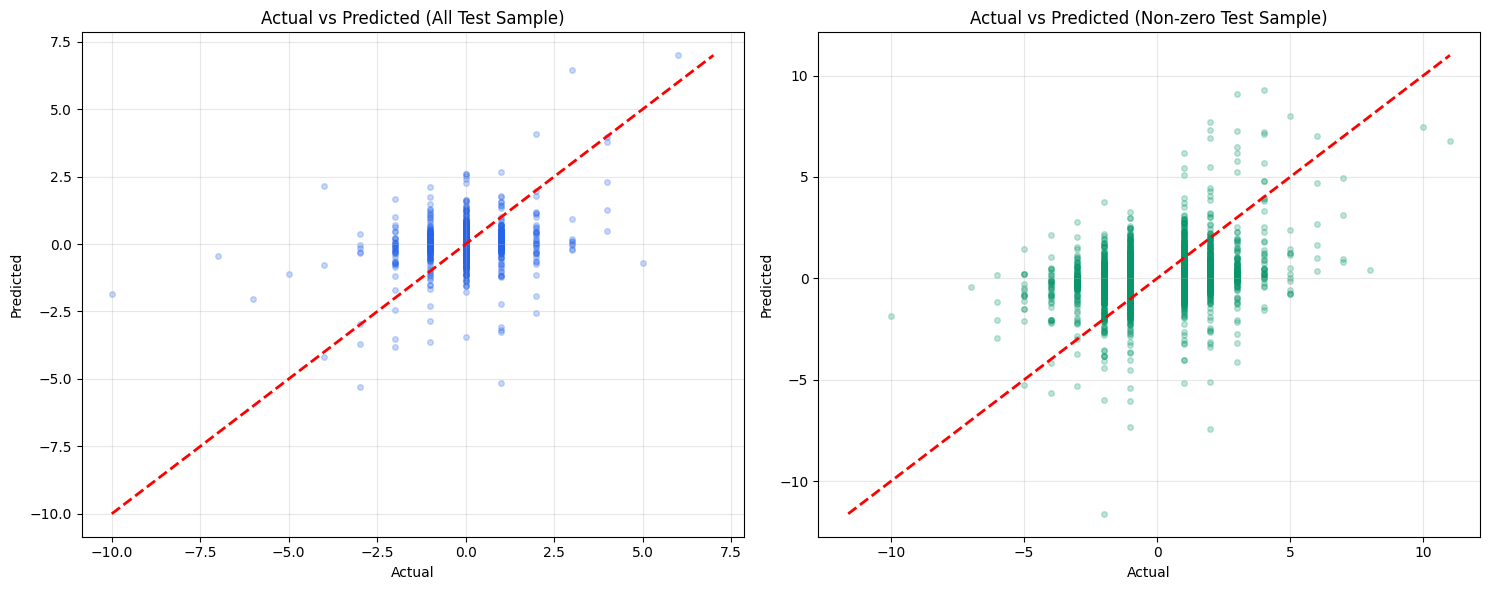

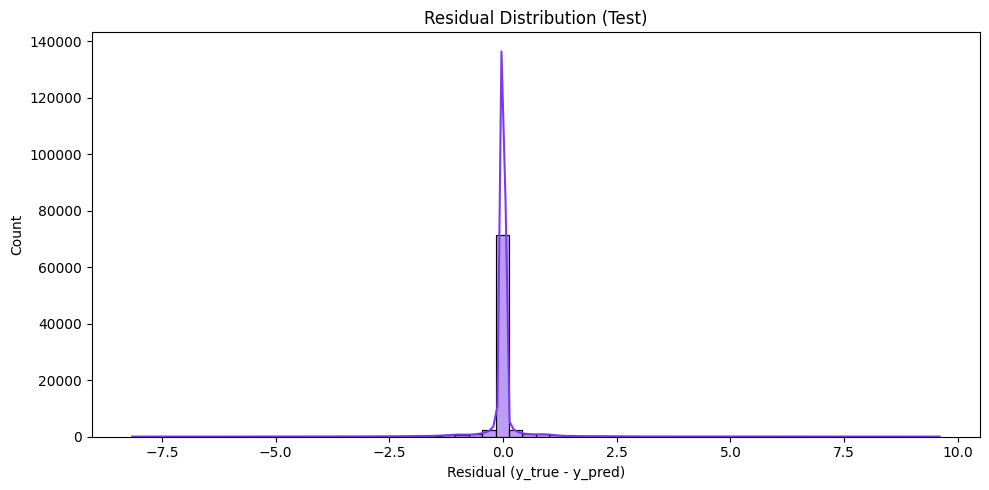

In [ ]:
# Plot diagnostics
sample_n = min(8000, len(y_test))
idx = np.random.default_rng(42).choice(len(y_test), size=sample_n, replace=False)

y_true_s = y_test.iloc[idx].to_numpy()
y_pred_s = pred_test[idx]

nz = y_test != 0
nz_idx = np.where(nz.to_numpy())[0]
if len(nz_idx) > 0:
    nz_n = min(8000, len(nz_idx))
    nz_sample = np.random.default_rng(42).choice(nz_idx, size=nz_n, replace=False)
    y_true_nz = y_test.iloc[nz_sample].to_numpy()
    y_pred_nz = pred_test[nz_sample]
else:
    y_true_nz = np.array([])
    y_pred_nz = np.array([])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_true_s, y_pred_s, alpha=0.25, s=16, color='#2563eb')
mn = float(min(y_true_s.min(), y_pred_s.min()))
mx = float(max(y_true_s.max(), y_pred_s.max()))
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted (All Test Sample)')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].grid(alpha=0.3)

if len(y_true_nz) > 0:
    axes[1].scatter(y_true_nz, y_pred_nz, alpha=0.25, s=16, color='#059669')
    mn2 = float(min(y_true_nz.min(), y_pred_nz.min()))
    mx2 = float(max(y_true_nz.max(), y_pred_nz.max()))
    axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', lw=2)
    axes[1].set_title('Actual vs Predicted (Non-zero Test Sample)')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No non-zero rows', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

residuals = y_test.to_numpy() - pred_test
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=60, kde=True, color='#7c3aed')
plt.title('Residual Distribution (Test)')
plt.xlabel('Residual (y_true - y_pred)')
plt.tight_layout()
plt.show()


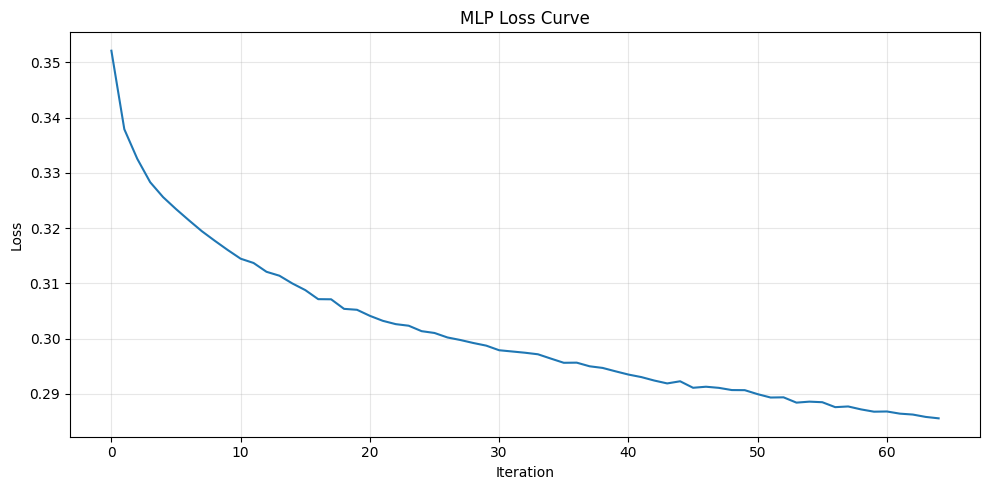

In [ ]:
# MLP-specific plot: training loss curve (if available)
try:
    reg = model.regressor_.named_steps['mlp']
    if hasattr(reg, 'loss_curve_') and len(reg.loss_curve_) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(reg.loss_curve_)
        plt.title('MLP Loss Curve')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Loss curve unavailable:', e)
